In [4]:
import numpy as np
import random

import pickle as pkl
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from tqdm import tqdm
from one.api import ONE
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from ibl_info.utils import check_config
from ibl_info.rsa_regression import (
    ideal_rsa_matrices,
    run_rsa_regression,
    simpler_rsa_matrices,
    run_rsa_regression_with_reward,
    dynamic_rsa_matrices,
    plot_rsa_dynamics,
    plot_rsa_summary_bars,
)
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore
from ibl_info.manifold import (
    plot_pcas_separate_decomposition,
    plot_pcas_separate_decomposition_adapted,
)
import warnings

warnings.filterwarnings("ignore")

In [5]:
%load_ext autoreload
%autoreload 2

In [6]:
from ibl_info.utils import check_config

In [7]:
with open("../data/generated/manifold/bwm_accumulated_data_correct_3_actionkernel.pkl", "rb") as f:
    dx_manifold = pkl.load(f)

In [8]:
conditions = [
    "L_Cong_Corr",
    "L_Cong_Err",
    "R_Incong_Corr",
    "R_Incong_Err",
    "R_Cong_Corr",
    "R_Cong_Err",
    "L_Incong_Corr",
    "L_Incong_Err",
]

In [30]:
session_matrices = dx_manifold["GRN"]["Quiescent"]

In [31]:
pop_matrix = np.vstack(session_matrices)

In [39]:
len(session_matrices), len(session_matrices[3]), len(session_matrices[0][0])

(14, 22, 400)

In [40]:
# sessions x neurons x conditions x bins

In [66]:
def plot_pcas_across_sessions(accumulated_data, region, cond_names):
    """
    Fits PCA on 'Corr' trial segments and projects 'Err' segments.
    Works with a list of session matrices per region/epoch.
    """
    n_conditions = len(cond_names)
    corr_indices = [i for i, name in enumerate(cond_names) if "Corr" in name]

    epochs_ordered = ["Quiescent"]
    for i, epoch_name in enumerate(epochs_ordered):
        fig = plt.figure(figsize=(24, 5))
        if epoch_name not in accumulated_data[region]:
            continue

        session_list = accumulated_data[region][epoch_name]
        if not session_list:
            continue
        pop_matrix = np.vstack(session_list)

        n_total_bins = pop_matrix.shape[1]
        bins_per_cond = n_total_bins // n_conditions

        fit_slices = []
        for idx in corr_indices:
            start = idx * bins_per_cond
            end = (idx + 1) * bins_per_cond
            fit_slices.append(pop_matrix[:, start:end])

        fit_data = np.hstack(fit_slices)  # Only 'Corr' segments
        # print("Fit data:", fit_data.shape)
        # print("Pop Matrix:", pop_matrix.shape)

        pca = PCA(n_components=3)
        pca.fit(fit_data.T)

        X_embedded = pca.transform(pop_matrix.T)  # (Total_Bins_All_Conds, 3)

        trajs = X_embedded.reshape(n_conditions, bins_per_cond, 3)

        ax = fig.add_subplot(1, 3, 1, projection="3d")
        cmap = plt.get_cmap("tab10")

        for c in range(n_conditions):
            is_error = "Err" in cond_names[c]
            color = cmap(c % 10)

            ax.plot(
                trajs[c, :, 0],
                trajs[c, :, 1],
                trajs[c, :, 2],
                color=color,
                label=cond_names[c] if i == 0 else "",
                lw=2 if not is_error else 1.2,
                linestyle="-",
                alpha=0.8 if not is_error else 0.25,
            )

            # Marker at the start of each trajectory
            ax.scatter(trajs[c, 0, 0], trajs[c, 0, 1], trajs[c, 0, 2], color=color, s=20)
            ax.scatter(
                trajs[c, -1, 0], trajs[c, -1, 1], trajs[c, -1, 2], color=color, s=20, marker="x"
            )

        if i == 0:
            ax.legend(loc="upper left", fontsize="x-small", frameon=False)
    ax.set_title(f"{region}: Quiscent epoch")
    plt.tight_layout()
    plt.show()

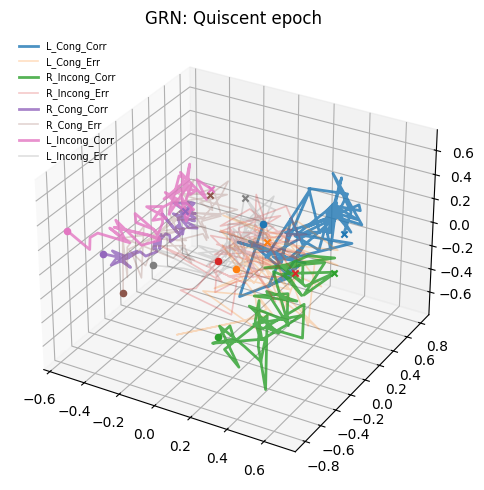

In [67]:
for rx in dx_manifold.keys():
    plot_pcas_across_sessions(dx_manifold, "GRN", cond_names=conditions)
    break

In [ ]:
import numpy as np
import pandas as pd


def generate_synthetic_neural_data(
    trial_df,
    num_neurons=100,
    stim_col="stimulus_side",
    prior_col="action_kernel_prior",
    outcome_col="feedbackType",
):
    """
    Generates synthetic neural spike counts based on real behavioral data using an LNP model.

    Parameters:
    - trial_df: pandas DataFrame containing the behavioral data.
    - num_neurons: int, total number of neurons to simulate.
    - stim_col: str, name of the column for stimulus side (-1 or 1).
    - prior_col: str, name of the column for the action-kernel prior.

    Returns:
    - synthetic_spikes: numpy array of shape (num_trials, num_neurons) with Poisson spike counts.
    - W: numpy array of shape (num_neurons, 4) containing the ground truth tuning weights.
    - lambda_rate: numpy array of shape (num_trials, num_neurons) with the expected firing rates.
    """

    num_trials = len(trial_df)
    stimulus = trial_df[stim_col].values
    action_kernel = trial_df[prior_col].values
    prev_outcome = trial_df[outcome_col].shift(1).fillna(0).values
    X = np.column_stack((np.ones(num_trials), stimulus, action_kernel, prev_outcome))

    W = np.zeros((num_neurons, 4))

    n_pop1 = int(num_neurons * 0.3)
    n_pop2 = int(num_neurons * 0.3)
    n_pop3 = num_neurons - (n_pop1 + n_pop2)

    idx1, idx2 = n_pop1, n_pop1 + n_pop2

    # Population 1: "Sensory" Neurons
    W[0:idx1, 0] = 1.5
    W[0:idx1, 1] = np.random.normal(0.8, 0.2, n_pop1) * np.random.choice([-1, 1], n_pop1)

    # Population 2: "Prior" Neurons
    W[idx1:idx2, 0] = 1.0
    W[idx1:idx2, 2] = np.random.normal(0.6, 0.2, n_pop2) * np.random.choice([-1, 1], n_pop2)

    # Population 3: "Mixed
    W[idx2:, 0] = 1.2
    W[idx2:, 1] = np.random.normal(0.4, 0.2, n_pop3)
    W[idx2:, 2] = np.random.normal(0.3, 0.1, n_pop3)
    W[idx2:, 3] = np.random.normal(0.7, 0.2, n_pop3)

    log_lambda = X @ W.T

    lambda_rate = np.exp(log_lambda)
    lambda_rate = np.clip(lambda_rate, 0, 100)  # Cap to prevent overflow

    synthetic_spikes = np.random.poisson(lambda_rate)

    return synthetic_spikes, W, lambda_rate